# Modelos por dominio geológico

Entrenamos un XGBoost dedicado por cada tipo con masa crítica:
- **Porphyry** (395 depósitos)
- **VMS** (425)
- **Sediment-Hosted** (104)

Descartamos Magmatic sulfide (36) e IOCG (29) por poca data.

Persistimos los tres modelos en `models/domain/` como `DomainRegressor` y comparamos contra el baseline global (`02_datos_enriquecidos`: R² test = 0.371).

## 1. Cargar datos y armar features

Usamos los módulos reutilizables de `src/`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features.build_features import build_feature_matrix
from src.training.domain_regressor import DomainRegressor

sns.set_style("whitegrid")
np.random.seed(42)

In [2]:
DATA_DIR = "../data/external/Global-copper-deposit-dataset/"

X_all, y_log_all, deposit_type_all, feature_cols = build_feature_matrix(
    main_xlsx=DATA_DIR + "Global_Copper_Deposit_Main.xlsx",
    ages_xlsx=DATA_DIR + "MED_ages_reordered_20200131.xlsx",
)
print(f"Dataset completo: {X_all.shape}")
print(f"Distribución por tipo:\n{deposit_type_all.value_counts()}")

Dataset completo: (989, 96)
Distribución por tipo:
Deposit_type
VMS                 425
Porphyry            395
Sediment-Hosted     104
Magmatic sulfide     36
IOCG                 29
Name: count, dtype: int64


## 2. Filtrar a los tres dominios con masa crítica

In [3]:
DOMAINS = ["Porphyry", "VMS", "Sediment-Hosted"]

mask = deposit_type_all.isin(DOMAINS)
X = X_all.loc[mask].reset_index(drop=True)
y_log = y_log_all.loc[mask].reset_index(drop=True)
groups = deposit_type_all.loc[mask].reset_index(drop=True)

print(f"Dataset filtrado: {X.shape} ({mask.sum() / len(mask):.1%} del total)")
print(f"Por dominio:\n{groups.value_counts()}")

Dataset filtrado: (924, 96) (93.4% del total)
Por dominio:
Deposit_type
VMS                425
Porphyry           395
Sediment-Hosted    104
Name: count, dtype: int64


## 3. Split train/test estratificado por dominio

Mantenemos la proporción de cada tipo en ambos splits. 20% test, intocable hasta el final.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_log, y_test_log, g_train, g_test = train_test_split(
    X, y_log, groups, test_size=0.2, stratify=groups, random_state=42
)
y_train = np.expm1(y_train_log)
y_test = np.expm1(y_test_log)

print(f"Train: {X_train.shape} — {g_train.value_counts().to_dict()}")
print(f"Test:  {X_test.shape} — {g_test.value_counts().to_dict()}")

Train: (739, 96) — {'VMS': 340, 'Porphyry': 316, 'Sediment-Hosted': 83}
Test:  (185, 96) — {'VMS': 85, 'Porphyry': 79, 'Sediment-Hosted': 21}


## 4. Cross-validation por dominio

Entrenamos cada dominio por separado con CV para diagnosticar cuál se beneficia más del domaining. Usamos 5-fold para Porphyry/VMS y 3-fold para Sediment-Hosted (menos data).

In [5]:
from sklearn.model_selection import KFold, cross_val_score
from xgboost import XGBRegressor

BASE_PARAMS = dict(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

results = {}
for domain in DOMAINS:
    mask = (g_train == domain).values
    X_d = X_train.loc[mask]
    y_d = y_train_log.loc[mask]
    n_splits = 3 if len(X_d) < 200 else 5
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    model = XGBRegressor(**BASE_PARAMS)
    r2 = cross_val_score(model, X_d, y_d, cv=kf, scoring="r2")
    rmse = -cross_val_score(model, X_d, y_d, cv=kf, scoring="neg_root_mean_squared_error")
    results[domain] = {"n": len(X_d), "folds": n_splits,
                       "r2_mean": r2.mean(), "r2_std": r2.std(),
                       "rmse_mean": rmse.mean(), "rmse_std": rmse.std()}

cv_df = pd.DataFrame(results).T
print("CV por dominio (target en log1p):")
print(cv_df.round(3))
print(f"\nBaseline global (02_datos_enriquecidos): R² CV = 0.434 ± 0.116")

CV por dominio (target en log1p):
                     n  folds  r2_mean  r2_std  rmse_mean  rmse_std
Porphyry         316.0    5.0    0.114   0.056      0.128     0.010
VMS              340.0    5.0    0.179   0.075      0.368     0.011
Sediment-Hosted   83.0    3.0    0.256   0.101      0.364     0.048

Baseline global (02_datos_enriquecidos): R² CV = 0.434 ± 0.116


## 5. Entrenamiento final y persistencia

Entrenamos el `DomainRegressor` con todo el train set y lo guardamos.

In [6]:
dr = DomainRegressor(domains=DOMAINS, model_params=BASE_PARAMS)
dr.fit(X_train, y_train_log, g_train)

MODELS_DIR = Path("../models/domain")
dr.save(MODELS_DIR)
print(f"Modelos guardados en {MODELS_DIR.resolve()}")
print(f"Archivos: {[p.name for p in MODELS_DIR.iterdir()]}")

Modelos guardados en /home/alexander/machine-learning/copper-grade-estimation/models/domain
Archivos: ['Porphyry.pkl', 'VMS.pkl', 'Sediment-Hosted.pkl', 'meta.json']


## 6. Evaluación en test set

Predecimos en test usando el submodelo correspondiente a cada fila y comparamos contra el baseline global.

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_log = dr.predict(X_test, g_test)
y_pred = np.expm1(y_pred_log)

print("=== Test set — global ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.3f}")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

print("\n=== Test set — por dominio ===")
rows = []
for d in DOMAINS:
    m = (g_test == d).values
    rows.append({
        "dominio": d,
        "n_test": int(m.sum()),
        "RMSE": np.sqrt(mean_squared_error(y_test[m], y_pred[m])),
        "MAE":  mean_absolute_error(y_test[m], y_pred[m]),
        "R²":   r2_score(y_test[m], y_pred[m]),
    })
per_domain = pd.DataFrame(rows).set_index("dominio").round(3)
print(per_domain)
print(f"\nBaseline global (02, todos los tipos): R² test = 0.371")

=== Test set — global ===
RMSE: 1.269
MAE:  0.664
R²:   0.263

=== Test set — por dominio ===
                 n_test   RMSE    MAE     R²
dominio                                     
Porphyry             79  0.213  0.165  0.117
VMS                  85  1.283  0.957 -0.048
Sediment-Hosted      21  2.710  1.356  0.000

Baseline global (02, todos los tipos): R² test = 0.371


## 7. Feature importance por dominio

Cada modelo aprende qué features pesan más en su tipo — esto valida si el domaining expone señales distintas (ej: tonelaje importa más en Porphyry, mineralogía en VMS).

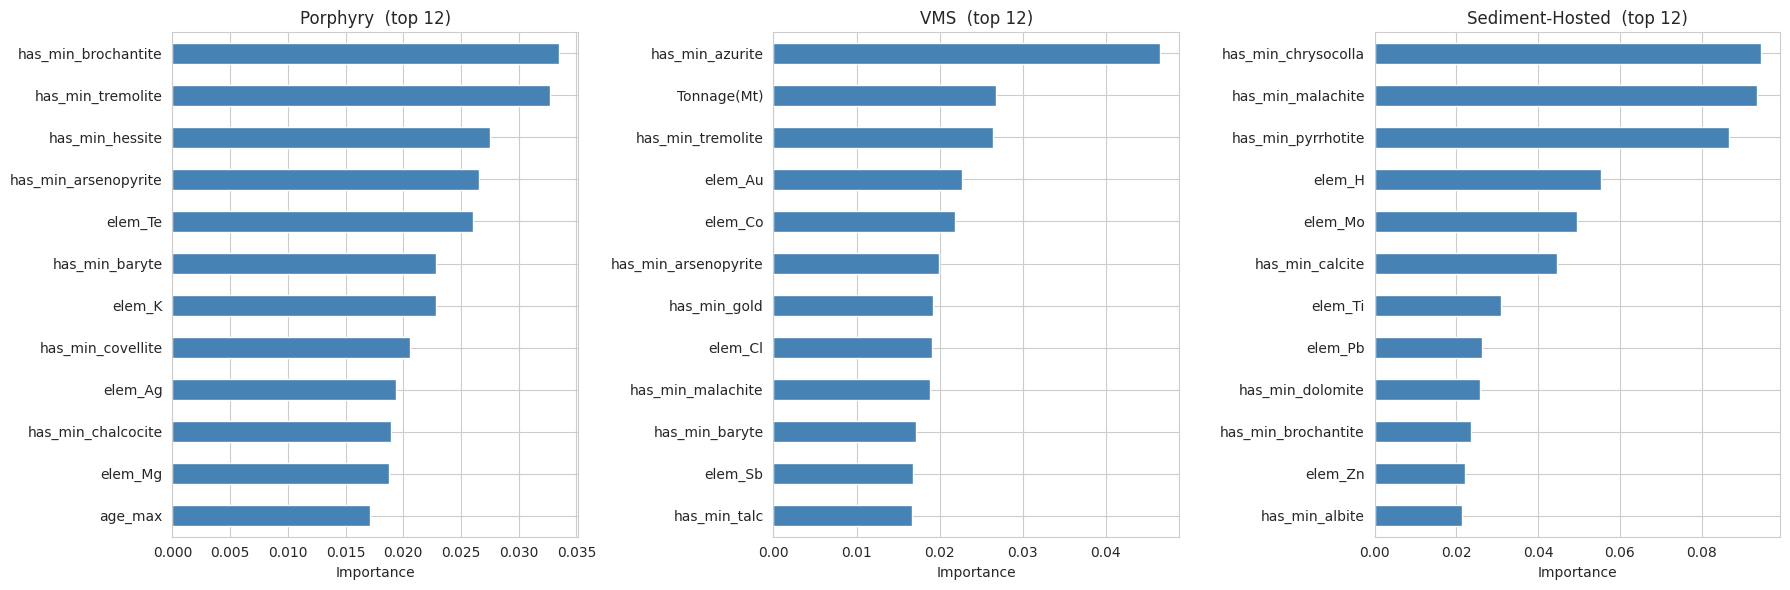

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, domain in zip(axes, DOMAINS):
    imp = pd.Series(
        dr.models_[domain].feature_importances_,
        index=feature_cols,
    ).sort_values(ascending=False).head(12)
    imp[::-1].plot.barh(ax=ax, color="steelblue")
    ax.set_title(f"{domain}  (top 12)")
    ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 8. Predicciones vs real (diagnóstico visual)

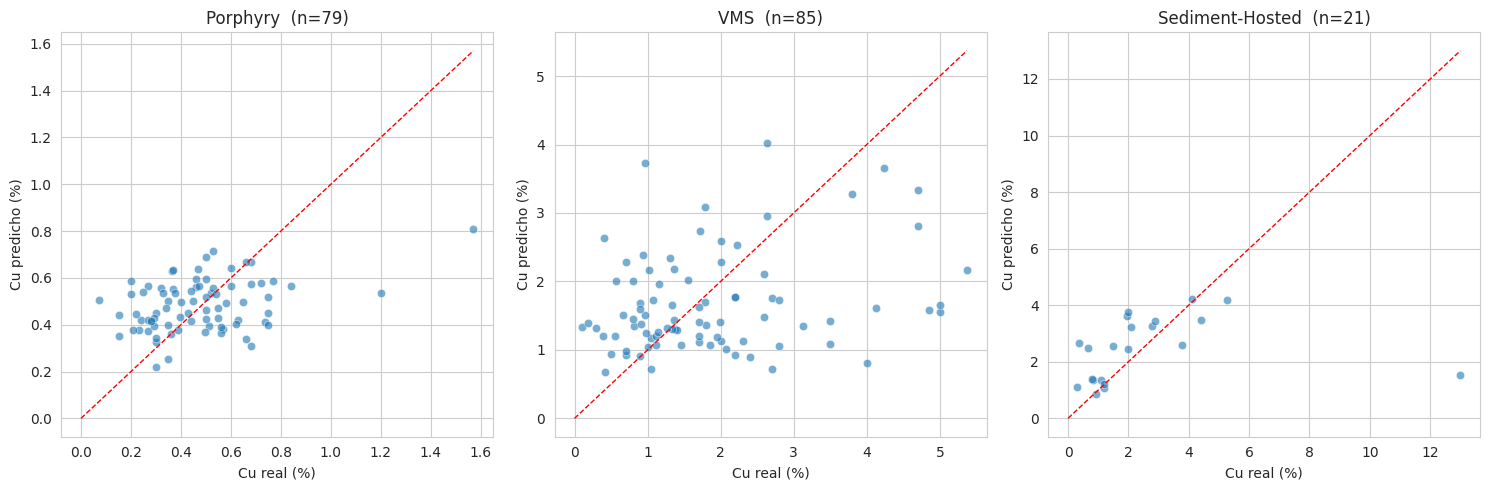

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, d in zip(axes, DOMAINS):
    m = (g_test == d).values
    ax.scatter(y_test[m], y_pred[m], alpha=0.6, edgecolor="white", linewidth=0.5)
    lim = max(y_test[m].max(), y_pred[m].max())
    ax.plot([0, lim], [0, lim], "r--", linewidth=1)
    ax.set_xlabel("Cu real (%)")
    ax.set_ylabel("Cu predicho (%)")
    ax.set_title(f"{d}  (n={m.sum()})")
plt.tight_layout()
plt.show()